# $\mathbb{Z}_2^F \times \mathbb{Z}_2$ state check

Created: 17-06-2026

Objectives:
* Create Hamiltoniains for $G_f = \mathbb{Z}_2^F \times \mathbb{Z}_2^T$ interpolating from $n_1=0$ to $n_1=1$ Hamiltonians.
* Implement defect operator procedure, see what results we get.

# Imports

In [1]:
from time import time

In [2]:
import numpy as np

In [3]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [4]:
import matplotlib.pyplot as plt

In [5]:
from tqdm import tqdm

In [6]:
from functools import reduce
from operator import mul
from itertools import product

In [7]:
import quimb.tensor as qtn
import quimb as qu

In [8]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [9]:
from humanize import naturalsize

# Definitions

In [10]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [11]:
np_X = np.array([
    [0,1],
    [1,0]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [12]:
qu_X = qtn.Tensor(
    np_X,
    inds=['k', 'b'],
    tags='X'
)

In [13]:
np_I = np.array([
    [1,0],
    [0,1]
])

In [14]:
qu_I = qtn.Tensor(
    np_I,
    inds=['k', 'b'],
    tags='I'
)

In [15]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [16]:
def get_multisite_qu_I(num_sites):
    np_many_I = multikron([np_I]*num_sites)

    out = qtn.Tensor(
        np_many_I,
        inds=['k', 'b'],
        tags='mulit_site_I',
    )

    return out

In [17]:
# Fermion parity on fermion sites
qu_FP = qtn.Tensor(np_Z, inds=['k', 'b'])

In [18]:
def get_multisite_qu_FP(sites):
    # Assuming fermion sites are on odd sites
    arrays = [
        (np_Z if (i%2) else np_I)
        for i in sites
    ]

    np_multisite_FP = multikron(arrays)

    out = qtn.Tensor(
        np_multisite_FP,
        inds=['k', 'b'],
        tags='multisite_FP',
    )

    return out

## Construct states

In [19]:
L = 8

In [20]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [21]:
# keys: (g_out, g_in)

spin_ops_dict = {
    (0,0): [("I", 0.5), ("z", 0.5)],
    (1,1): [("I", 0.5), ("z", -0.5)],
    (0,1): [("+", 0.5),],
    (1,0): [("-", 0.5),]
}

In [22]:
def get_fermionic_op_string(group_quad):
    g_left, g_in, g_out, g_right = group_quad

    out_string = ''
    out_indices = list()

    if (g_left + g_out) % 2:
        out_string += '+'
        out_indices.append(0)
    if (g_out + g_right) % 2:
        out_string += '+'
        out_indices.append(1)
    if (g_in + g_right) % 2:
        out_string += '-'
        out_indices.append(1)
    if (g_left + g_in) % 2:
        out_string += '-'
        out_indices.append(0)

    return (out_string, out_indices)

In [23]:
def get_nontriv_group_quad_terms(group_quad, L, strength_scaling):
    g_left, g_in, g_out, g_right = group_quad

    left_op = spin_ops_dict[(g_left, g_left)]
    mid_op = spin_ops_dict[(g_out, g_in)]
    right_op = spin_ops_dict[(g_right, g_right)]

    op_triples = product(left_op, mid_op, right_op)

    terms = list()

    for left_pair, mid_pair, right_pair in op_triples:
        left_string, left_strength = left_pair
        mid_string, mid_strength = mid_pair
        right_string, right_strength = right_pair

        spin_string = f"{left_string}{mid_string}{right_string}"
        strength = (
            -(1/2)
            *left_strength
            *mid_strength
            *right_strength
            *strength_scaling
        )

        ferm_op_string, ferm_indices = get_fermionic_op_string(group_quad)
        op_string = f"{spin_string}|{ferm_op_string}"


        base_index = [0, 1, 2, *ferm_indices]
        all_indices = [
            [(x+i)%L for x in base_index]
            for i in range(L)
        ]

        current_term = [
            op_string, [[strength, *indices] for indices in all_indices]
        ]

        terms.append(current_term)

    return terms

In [24]:
triv_fermion_terms_phases = [
    ('I', 1),
    ('n', -1)
]

In [59]:
def get_triv_group_quad_terms(group_quad, L, strength_scaling):
    g_left, g_in, g_out, g_right = group_quad

    left_op = spin_ops_dict[(g_left, g_left)]
    mid_op = spin_ops_dict[(g_out, g_in)]
    right_op = spin_ops_dict[(g_right, g_right)]

    op_triples = product(left_op, mid_op, right_op)

    terms = list()

    for left_pair, mid_pair, right_pair in op_triples:
        left_string, left_strength = left_pair
        mid_string, mid_strength = mid_pair
        right_string, right_strength = right_pair

        # To be honest I expect to need 1/2 here not 1/8...
        # but it works.
        spin_string = f"{left_string}{mid_string}{right_string}"
        strength = (
            -(1/8)
            *left_strength
            *mid_strength
            *right_strength
            *strength_scaling
        )

        for pair_1, pair_2 in product(triv_fermion_terms_phases, repeat=2):
            fp_op_1, fp_phase_1 = pair_1
            fp_op_2, fp_phase_2 = pair_2
            
            op_string = f"{spin_string}|{fp_op_1}{fp_op_2}"
    
            base_index = [0, 1, 2, 0, 1]
            all_indices = [
                [(x+i)%L for x in base_index]
                for i in range(L)
            ]
    
            current_term = [
                op_string, [[strength, *indices] for indices in all_indices]
            ]
    
            terms.append(current_term)

    return terms

In [50]:
def get_triv_to_n1_non_triv_hamiltonian(t, L):
    spin_basis = spin_basis_1d(L)
    fermion_basis = spinless_fermion_basis_1d(L)
    basis = tensor_basis(spin_basis, fermion_basis)

    triv_terms = [
        l for group_quad in group_quads
        for l in get_triv_group_quad_terms(group_quad, L, 1-t)
    ]

    non_triv_terms = [
        l for group_quad in group_quads
        for l in get_nontriv_group_quad_terms(group_quad, L, t)
    ]

    all_terms = triv_terms + non_triv_terms

    h = hamiltonian(
        all_terms,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return h

In [51]:
L = 8

In [52]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [53]:
parameters = np.linspace(0, 1, 21)

In [54]:
group_quads = list(product([0,1], repeat=4))

In [55]:
energies = list()
groundstates = list()

for t in tqdm(parameters):
    h = get_triv_to_n1_non_triv_hamiltonian(t, L)
    e, psi = h.eigsh(k=1, which='SA')

    energies.append(e)
    groundstates.append(psi)

  0%|                                                                                                    | 0/21 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_91656/3934320765.py:18: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(
100%|███████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:23<00:00,  1.10s/it]


In [56]:
#A = non_triv_hamiltonian.toarray()
#np.linalg.norm(A - A.conj().T)

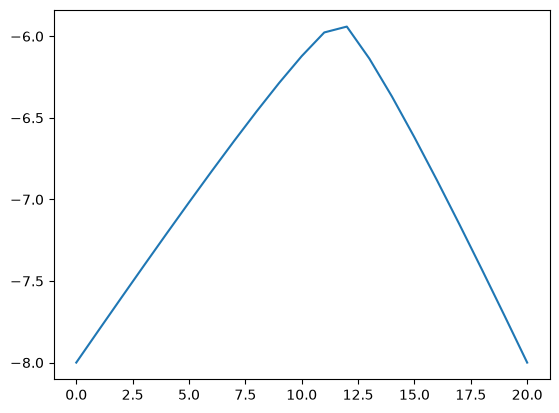

In [57]:
plt.plot(energies)

## Extract MPS

In [63]:
# I don't think we're using this anymore
def get_rho_A_purity(A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A
    t2 = A.conj().reindex(transpose_dict)
    t3 = A.reindex(transpose_dict | alternative_vertical_index_dict)
    t4 = A.conj().reindex(alternative_vertical_index_dict)

    t = (t1 & t2 & t3 & t4)

    return jnp.real(t.contract())

In [64]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [65]:
def normalize_A(A):
    # Ensure trace = 1
    trace = jnp.real((A & A.conj()).contract())
    A = A.multiply(trace**(-0.5), spread_over=A.num_tensors)

    # Equalize norms
    norms = [
        jnp.sqrt(jnp.real((a & a.conj()).contract()))
        for a in A.tensors
    ]
    geometric_mean_norms = jnp.pow(reduce(mul, norms), 1/(A.num_tensors))

    for a, norm in zip(A.tensors, norms):
        a.modify(data=a.data*geometric_mean_norms/norm)

    return A

In [66]:
alternative_vertical_index_dict = {
    'vLV': 'vLV_alt',
    'vRV': 'vRV_alt'
}

In [67]:
def get_rho_A_purity(A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A
    t2 = A.conj().reindex(transpose_dict)
    t3 = A.reindex(transpose_dict | alternative_vertical_index_dict)
    t4 = A.conj().reindex(alternative_vertical_index_dict)

    t = (t1 & t2 & t3 & t4)

    return jnp.real(t.contract())

In [68]:
def get_rho_A_rho_overlap(rho, A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A.reindex(transpose_dict)
    t2 = A.conj()

    t = (rho & t1 & t2)

    return jnp.real(t.contract())

In [69]:
def loss_func(A, rho, rho_purity):

    out = jnp.real(
        rho_purity
        + get_rho_A_purity(A)
        -2*get_rho_A_rho_overlap(rho, A)
    )

    return out

In [70]:
def get_initial_rho_mps_representation(domains_dict):
    symmetry_sites = domains_dict['symmetry_sites']
    horizontal_bond_dimension = domains_dict['mps_horizontal_bond_dimension']
    vertical_bond_dimension = domains_dict['mps_vertical_bond_dimension']

    i = symmetry_sites[0]
    leftmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            vertical_bond_dimension,
            2,
            horizontal_bond_dimension
        )),
        inds=('vLV', f'k{i}', f'vH{i}')
    )

    interior_mps_tensors = [
        qtn.Tensor(
            data=random_uniform_complex((
                horizontal_bond_dimension,
                2,
                horizontal_bond_dimension
            )),
            inds=(f'vH{i-1}', f'k{i}', f'vH{i}')
        )
        for i in symmetry_sites[1:-1]
    ]

    i = symmetry_sites[-1]
    rightmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            horizontal_bond_dimension,
            2,
            vertical_bond_dimension
        )),
        inds=(f'vH{i-1}', f'k{i}', 'vRV')
    )

    mps_tensors = [
        leftmost_mps_tensor,
        *interior_mps_tensors,
        rightmost_mps_tensor
    ]
    
    A = qtn.TensorNetwork(mps_tensors)

    return A

In [71]:
def get_rho_mps_representation(qt_rho, rho_purity, domains_dict):
    A = get_initial_rho_mps_representation(domains_dict)

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=500)

    tnopt = qtn.TNOptimizer(
        A_opt,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="adam",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=2000)

    return A_opt, tnopt.losses, tnopt.loss_best

In [72]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [73]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [74]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

In [75]:
def get_left_right_schmidt_values(quspin_psi, domains_dict):
    inds = (
        [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
        + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
    )

    qt_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )

    rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )
    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    rho_lr = (
        rho
        .reindex({f'k{i}': f'b{i}' for i in central_sites})
        .contract()
    )

    left_defect_inds = (
        [f'k{i}' for i in domains_dict['left_defect_sites']]
        + [f'b{i}' for i in domains_dict['left_defect_sites']]
    )

    split_rho_lr = qtn.tensor_core.tensor_split(
        rho_lr,
        left_inds=left_defect_inds,
        absorb=None,
        bond_ind='vH'
    )

    out = split_rho_lr.tensors[1].data

    return out

## Defect operators and indices

In [76]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl, kr, bl, br]
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl'), edm.ind_size('kl')),
        inds=['kl', 'bl'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br'), edm.ind_size('kr')),
        inds=['kr', 'br'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl': 'bl', 'bl':'kl'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr', 'br'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr': 'br', 'br':'kr'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl', 'bl'])

    return (left_defect_op, right_defect_op), scores

In [77]:
def get_rho(mps_decomp, domains_dict):
    # rho_tilde is a reduced density matrix with the bra part complex conjugated
    A = mps_decomp

    # Left side
    A_l = A.tensors[next(iter(A.ind_map['vLV']))]
    k_left_ind = min(domains_dict['symmetry_sites'])
    dummy_left_index = f'vH{k_left_ind}'
    
    tn_l = (
        A_l
        &
        A_l.conj().reindex({
            f'k{k_left_ind}': f'b{k_left_ind}',
            dummy_left_index: 'dl',
        })
    )
    tn_l = tn_l.contract()

    left_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=[f'k{k_left_ind}', dummy_left_index],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    # Right side
    A_r = A.tensors[next(iter(A.ind_map['vRV']))]
    k_right_ind = max(domains_dict['symmetry_sites'])
    dummy_right_index = f'vH{k_right_ind-1}'

    tn_r = (
        A_r
        &
        A_r.conj().reindex({
            f'k{k_right_ind}': f'b{k_right_ind}',
            dummy_right_index: 'dr',
        })
    )
    tn_r = tn_r.contract()

    right_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=[f'k{k_right_ind}', dummy_right_index],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    ket_tensors = [
        *left_decomp.tensors[:-1],
        *[t for t in mps_decomp.tensors[1:-1]],
        *right_decomp.tensors[:-1]
    ]

    bra_tensors = [
        left_decomp.tensors[-1].reindex({'dl': dummy_left_index}),
        *[
            t.conj().reindex({f'k{i}': f'b{i}'})
            for t, i in zip(mps_decomp.tensors[1:-1], domains_dict['symmetry_sites'][1:-1])
        ],
        right_decomp.tensors[-1].reindex({'dr': dummy_right_index})
    ]

    ket_tn = qtn.TensorNetwork(ket_tensors)
    bra_tn = qtn.TensorNetwork(bra_tensors).mangle_inner_()

    rho = ket_tn & bra_tn

    return rho

In [78]:
def get_edm_from_rho(rho, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_gates = [
        qu_X.reindex({'k': f'i{i}', 'b':f'b{i}'})
        for i in domains_dict['left_defect_sites']
        if i%2 == 0
    ]

    central_gates = [
        qu_X.reindex({'k': f'k{i}', 'b':f'b{i}'})
        for i in central_sites
        if i%2 == 0
    ]

    right_gates = [
        qu_X.reindex({'k': f'i{i}', 'b':f'b{i}'})
        for i in domains_dict['right_defect_sites']
        if i%2 == 0
    ]

    rho_reindex_dict = (
        {
            f'b{i}': f'i{i}'
            for i in domains_dict['left_defect_sites']
            if i%2 == 0
        }
        | {
            f'b{i}': f'i{i}'
            for i in domains_dict['right_defect_sites']
            if i%2 == 0
        }
        | {
            f'b{i}': f'k{i}'
            for i in central_sites
            if i%2 == 1
        }
    )

    all_tensors = [
        rho.reindex(rho_reindex_dict),
        *left_gates,
        *central_gates,
        *right_gates
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = (
        qtn.TensorNetwork(all_tensors)
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [79]:
def get_defect_ops_and_indices_from_mps_decomposition(
    qt_rho, mps_decomp, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    rho = get_rho(mps_decomp, domains_dict)

    edm = get_edm_from_rho(rho, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        overlaps,
        overlap
    )

    return out

# Extract and check results

In [80]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10, 11],
    'fdlu_depth': 0,
    'fdlu_offset': 0,
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [81]:
inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

In [82]:
opt_results = list()
defect_results = list()

for psi in tqdm(groundstates):
    qt_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )

    rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])

    rho_purity = get_purity_from_quimb_rdm(rho)
    opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)

    defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(
        rho,
        opt_out[0],
        domains_dict
    )

    opt_results.append(opt_out)
    defect_results.append(defect_opt_out)

  0%|                                                                                                    | 0/21 [00:00<?, ?it/s]/Users/kierancooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████████████| 21/21 [01:55<00:00,  5.49s/it]


## Check results

In [86]:
[l[1][-1] for l in opt_results]

[4.76837158203125e-07,
 3.337860107421875e-06,
 5.7220458984375e-06,
 4.76837158203125e-06,
 5.4836273193359375e-06,
 7.152557373046875e-06,
 6.67572021484375e-06,
 1.4901161193847656e-05,
 2.3245811462402344e-05,
 8.940696716308594e-06,
 1.704692840576172e-05,
 3.1113624572753906e-05,
 5.412101745605469e-05,
 4.9501657485961914e-05,
 1.5527009963989258e-05,
 3.635883331298828e-06,
 1.4007091522216797e-06,
 5.066394805908203e-07,
 3.069639205932617e-06,
 7.152557373046875e-07,
 2.384185791015625e-07]

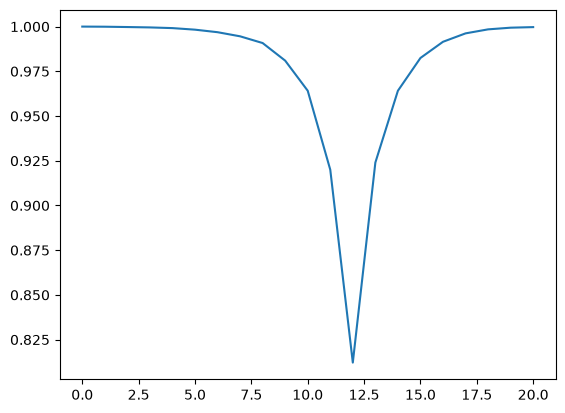

In [87]:
overlaps = [l[-1] for l in defect_results]
plt.plot(overlaps)

Curious.

In [88]:
indices = np.array([
    [l[3], l[4]]
    for l in defect_results
])

In [90]:
np.round(indices, 3)

array([[ 1.-0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.-0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.-0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.-0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.-0.j, -1.-0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.-0.j],
       [-1.-0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j]])

# Conclusions
Everything working as expected here, so the issue we are seeing in the TRS case is likely due to something non-trivial happening between TRS and fermionic nonsense.